In [1]:
!pip install pandas matplotlib seaborn -q


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datos de inflación mensual Argentina 2017-2023 (84 meses)
fechas = pd.date_range(start='2017-01', periods=84, freq='MS')

inflacion = [
    1.6, 1.8, 2.4, 2.6, 1.3, 1.2, 1.7, 1.4, 1.9, 1.5, 1.4, 3.1,  # 2017
    1.8, 2.4, 2.3, 2.7, 2.1, 3.7, 3.1, 3.9, 6.5, 5.4, 3.2, 2.6,  # 2018
    2.9, 3.8, 3.4, 3.4, 3.1, 2.7, 2.2, 4.0, 5.9, 5.3, 4.3, 3.7,  # 2019
    2.3, 2.0, 2.6, 1.5, 1.5, 2.2, 1.9, 2.7, 2.8, 3.8, 3.2, 4.0,  # 2020
    3.8, 2.5, 2.4, 3.0, 3.3, 3.2, 2.5, 3.0, 2.8, 6.2, 6.3, 7.4,  # 2021
    6.0, 5.1, 4.7, 4.2, 5.3, 7.0, 6.2, 6.3, 12.4, 8.3, 6.6, 4.9, # 2022
    6.0, 6.7, 7.8, 8.4, 9.6, 12.8, 8.8, 7.3, 12.7, 6.2, 8.3, 9.1 # 2023
]

df = pd.DataFrame({'fecha': fechas, 'inflacion_mensual': inflacion})
df['año'] = df['fecha'].dt.year

print(df.head(10))
print(f"\nDataset: {len(df)} meses de datos")

       fecha  inflacion_mensual   año
0 2017-01-01                1.6  2017
1 2017-02-01                1.8  2017
2 2017-03-01                2.4  2017
3 2017-04-01                2.6  2017
4 2017-05-01                1.3  2017
5 2017-06-01                1.2  2017
6 2017-07-01                1.7  2017
7 2017-08-01                1.4  2017
8 2017-09-01                1.9  2017
9 2017-10-01                1.5  2017

Dataset: 84 meses de datos


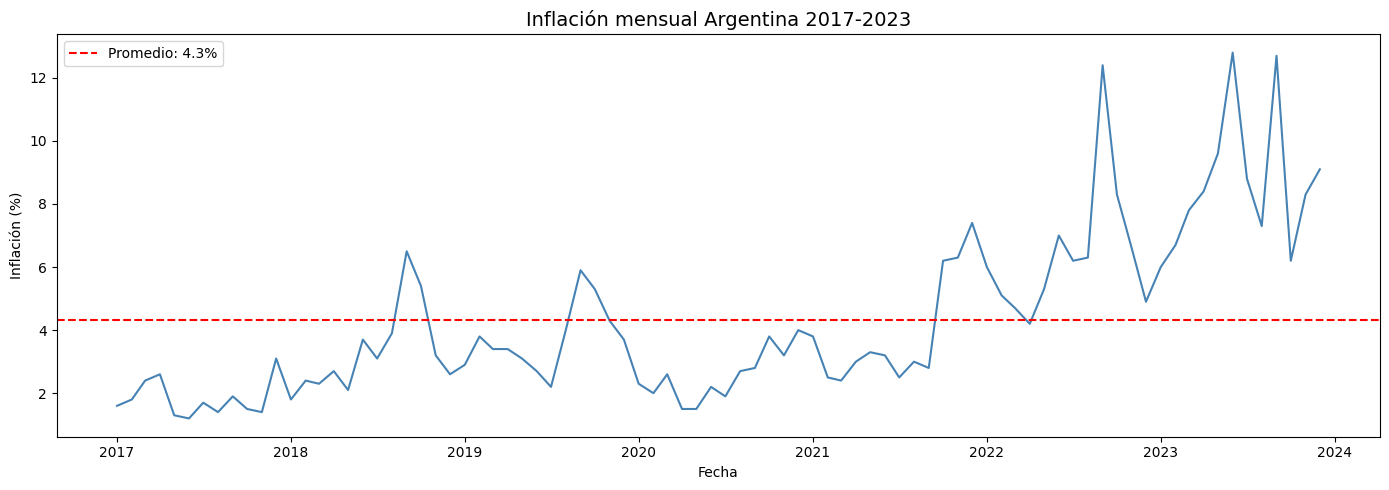

In [4]:
# Gráfico 1 - Inflación mensual a lo largo del tiempo
plt.figure(figsize=(14, 5))
plt.plot(df['fecha'], df['inflacion_mensual'], color='steelblue', linewidth=1.5)
plt.axhline(y=df['inflacion_mensual'].mean(), color='red', linestyle='--', label=f'Promedio: {df["inflacion_mensual"].mean():.1f}%')
plt.title('Inflación mensual Argentina 2017-2023', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Inflación (%)')
plt.legend()
plt.tight_layout()
plt.savefig('grafico1_serie_temporal.png', dpi=150)
plt.show()


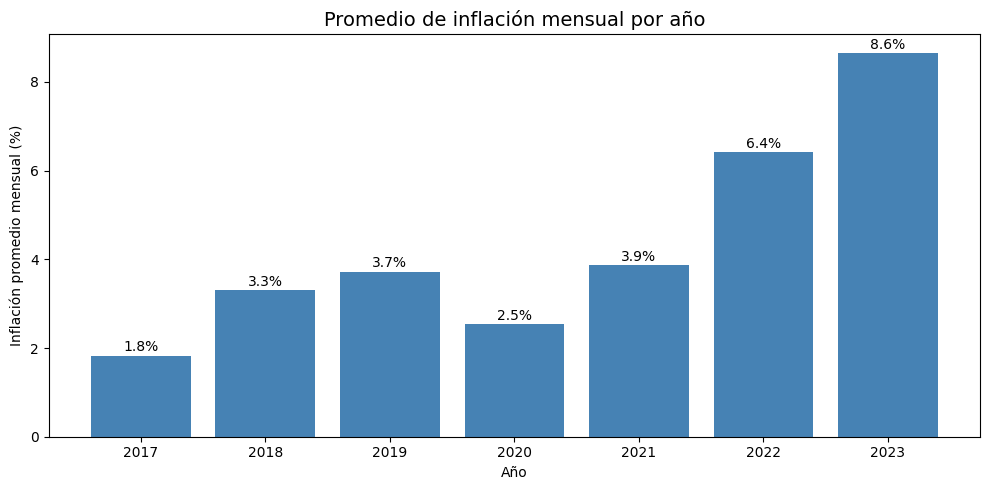

In [5]:
# Gráfico 2 - Inflación promedio por año
inflacion_anual = df.groupby('año')['inflacion_mensual'].mean().reset_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(inflacion_anual['año'], inflacion_anual['inflacion_mensual'], color='steelblue')
plt.title('Promedio de inflación mensual por año', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Inflación promedio mensual (%)')
for bar, val in zip(bars, inflacion_anual['inflacion_mensual']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('grafico2_por_año.png', dpi=150)
plt.show()


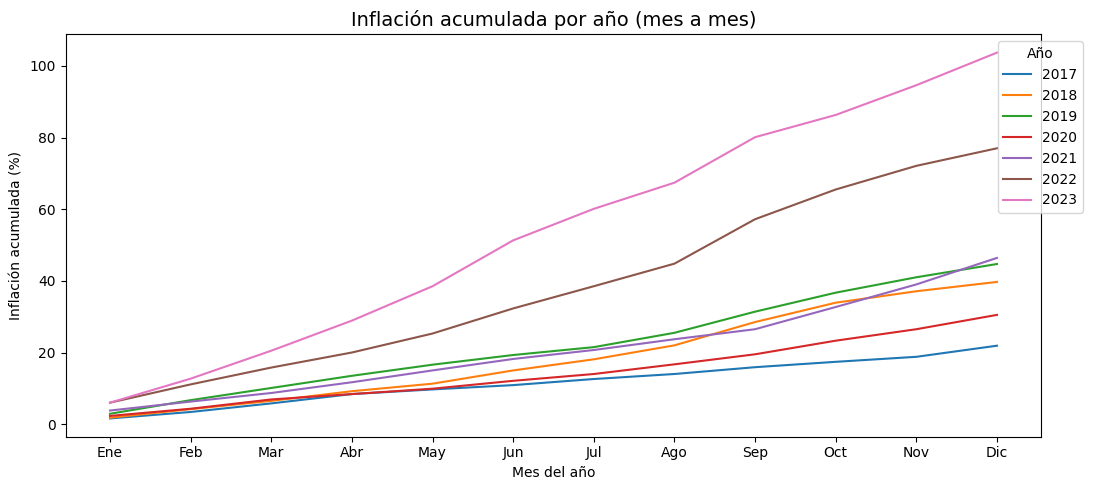

In [6]:
# Gráfico 3 - Inflación acumulada por año
df['inflacion_acumulada'] = df.groupby('año')['inflacion_mensual'].cumsum()

anios = df['año'].unique()
colors = plt.cm.tab10.colors

plt.figure(figsize=(12, 5))
for i, anio in enumerate(anios):
    subset = df[df['año'] == anio]
    meses = range(1, len(subset) + 1)
    plt.plot(meses, subset['inflacion_acumulada'], label=str(anio), color=colors[i])

plt.title('Inflación acumulada por año (mes a mes)', fontsize=14)
plt.xlabel('Mes del año')
plt.ylabel('Inflación acumulada (%)')
plt.xticks(range(1, 13), ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.legend(title='Año', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('grafico3_acumulada.png', dpi=150)
plt.show()


In [7]:
# Estadísticas finales
print("=== RESUMEN DEL ANÁLISIS ===\n")
print(f"Período analizado: 2017 - 2023")
print(f"Inflación mensual promedio: {df['inflacion_mensual'].mean():.1f}%")
print(f"Mes con mayor inflación: {df.loc[df['inflacion_mensual'].idxmax(), 'fecha'].strftime('%B %Y')} ({df['inflacion_mensual'].max():.1f}%)")
print(f"Mes con menor inflación: {df.loc[df['inflacion_mensual'].idxmin(), 'fecha'].strftime('%B %Y')} ({df['inflacion_mensual'].min():.1f}%)")
print(f"\nInflación acumulada por año:")
for anio in df['año'].unique():
    total = df[df['año'] == anio]['inflacion_mensual'].sum()
    print(f"  {anio}: {total:.1f}%")


=== RESUMEN DEL ANÁLISIS ===

Período analizado: 2017 - 2023
Inflación mensual promedio: 4.3%
Mes con mayor inflación: June 2023 (12.8%)
Mes con menor inflación: June 2017 (1.2%)

Inflación acumulada por año:
  2017: 21.9%
  2018: 39.7%
  2019: 44.7%
  2020: 30.5%
  2021: 46.4%
  2022: 77.0%
  2023: 103.7%


In [9]:
from google.colab import files
import os

# Verificamos qué archivos existen
print(os.listdir('/content'))

# Descargamos solo los gráficos (el notebook lo subimos diferente)
files.download('grafico1_serie_temporal.png')
files.download('grafico2_por_año.png')
files.download('grafico3_acumulada.png')


['.config', 'grafico3_acumulada.png', 'grafico2_por_año.png', 'grafico1_serie_temporal.png', 'sample_data']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>